# La capa de salida y su función de pérdida

Acompañamiento en código de **el catálogo de salidas** de la clase: la diapositiva que dice, para cada tarea, cuántas neuronas lleva la última capa, qué activación y qué loss le corresponde.

Es el espejo del notebook [`input-data-types.ipynb`](input-data-types.ipynb), y **usa las mismas 2000 casas**. Pero con una vuelta: ahí el precio era lo que se predecía, y acá **el precio es una entrada más**. Lo que se predice es otra cosa — cuántos días tarda en venderse, cuántas visitas recibe, si se vendió, en qué segmento cae, qué atributos tiene.

Ese giro es el punto de todo el notebook: **con el mismo dato de entrada, lo que cambia la última capa es la tarea, no el dato.**

**Cómo está armado.** Las entradas se resuelven **una sola vez** al principio — esa es la parte que ya se trabajó en el otro notebook — y después vamos **tarea por tarea**. Para cada una:

1. se mira el objetivo y qué forma tiene;
2. se entrena la salida **incorrecta**, la que parece razonable y no lo es;
3. se entrena la **correcta**, el par activación + loss que le toca;
4. se comparan con la métrica que corresponde a esa tarea.

**Al final**, la tabla de decisiones completa.

## El dataset

`output-layer-types.csv` son **las mismas 2000 casas** de `input-data-types.csv` — mismos `listing_id`, mismas columnas de entrada, precio incluido — más una columna objetivo por cada familia de salida:

| Columna | Qué es | Qué tarea es |
|---|---|---|
| `dias_para_vender` | días hasta la venta, **como fueron cargados** | un valor continuo |
| `dias_reales` | lo mismo, sin los errores de carga | (solo para medir con honestidad) |
| `visitas_semana` | visitas en la primera semana | un conteo |
| `se_vendio` | 0 o 1 | sí o no |
| `segmento` | `economica` · `media` · `premium` | una clase entre N |
| `tiene_pileta` · `apto_credito` · `a_reciclar` | 0 o 1 cada una | varias etiquetas a la vez |

El dataset es **sintético**, con semilla fija y una regla explícita por objetivo — está todo en [`output-layer-types-gen.py`](output-layer-types-gen.py). Tres cosas se pusieron a propósito porque son el argumento de cada sección:

- **`dias_para_vender` trae un 1,7% de fichas con la fecha mal cargada**, con días diez veces más grandes que los reales. Es el outlier que separa MSE de Huber, y está de verdad en los datos en vez de quedar en la teoría.
- **`visitas_semana` es Poisson de verdad**: su varianza crece con la media. Eso es lo que una salida lineal con MSE no puede representar.
- **`dias_para_vender` es heterocedástico**: la incertidumbre la manda el tipo de vivienda — un departamento se vende con una previsibilidad que una casa no tiene (`sigma` va de 5 a 30 días). Por eso las últimas dos secciones tienen algo real que mostrar.

### Declarar el tipo al cargar

Igual que en el otro notebook: qué es cada columna se dice **una sola vez, en el `read_csv`**, y después ninguna sección tiene que castear.

Lo único nuevo son los objetivos. Dos declaraciones que ya son decisiones de modelado:

- **`segmento` como categoría *ordenada*.** El orden económica < media < premium existe en el dominio. Y sin embargo — atención — la sección 4 lo va a tratar como **nominal**: un segmento no es un número, y predecir "2,3 de segmento" no significa nada. El orden sirve para leer la tabla, no para modelar.
- **`se_vendio` y las tres etiquetas como `float32`.** Son 0 y 1, y la loss los espera como floats, no como enteros ni como booleanos.

In [1]:
import numpy as np
import pandas as pd
import keras
from keras import layers
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ORDEN_ESTADO   = ["regular", "bueno", "muy bueno", "excelente"]
ORDEN_SEGMENTO = ["economica", "media", "premium"]
ETIQUETAS      = ["tiene_pileta", "apto_credito", "a_reciclar"]

df = pd.read_csv("output-layer-types.csv", dtype={
    "listing_id":    "int64",
    "m2":            "float32",
    "banos":         "float32",
    "ingreso_zona":  "float32",
    "tipo_vivienda": "category",
    "barrio":        "category",
    "codigo_postal": "category",
    "mes_venta":     "float32",
    "anio_alta":     "float32",
    "precio":        "float32",   # ahora es ENTRADA, no objetivo
    # --- objetivos ---
    "dias_para_vender": "float32",
    "dias_reales":      "float32",
    "visitas_semana":   "float32",
    "se_vendio":        "float32",
})
df["estado"]   = pd.Categorical(df.estado,   categories=ORDEN_ESTADO,   ordered=True)
df["segmento"] = pd.Categorical(df.segmento, categories=ORDEN_SEGMENTO, ordered=True)
df["tiene_cochera"] = df.tiene_cochera.astype("float32")
df[ETIQUETAS] = df[ETIQUETAS].astype("float32")

OBJETIVOS = ["dias_para_vender", "visitas_semana", "se_vendio", "segmento"] + ETIQUETAS
print(f"{len(df)} filas\n")
print(df[["listing_id", "m2", "precio"] + OBJETIVOS].head(5).to_string(index=False))

2000 filas

 listing_id    m2   precio  dias_para_vender  visitas_semana  se_vendio  segmento  tiene_pileta  apto_credito  a_reciclar
     271195 102.0 352432.0              52.0             6.0        1.0 economica           0.0           0.0         1.0
     916831  35.0 278612.0              72.0             3.0        0.0 economica           0.0           0.0         1.0
     951972 162.0 482470.0              73.0             1.0        0.0   premium           1.0           1.0         1.0
     199237  45.0 228560.0              85.0             0.0        1.0 economica           0.0           0.0         1.0
     538038 110.0 413319.0              77.0             5.0        0.0     media           0.0           1.0         0.0


In [2]:
pd.DataFrame({
    "dtype":     df[OBJETIVOS].dtypes.astype(str),
    "distintos": df[OBJETIVOS].nunique(),
    "minimo":    [df[c].min() if c != "segmento" else "-" for c in OBJETIVOS],
    "maximo":    [df[c].max() if c != "segmento" else "-" for c in OBJETIVOS],
    "ejemplos":  [", ".join(map(str, df[c].dropna().unique()[:3])) for c in OBJETIVOS],
})

,dtype,distintos,minimo,maximo,ejemplos
dias_para_vender,float32,184,1.0,1094.0,"52.0, 72.0, 73.0"
visitas_semana,float32,32,0.0,54.0,"6.0, 3.0, 1.0"
se_vendio,float32,2,0.0,1.0,"1.0, 0.0"
segmento,category,3,-,-,"economica, premium, media"
tiene_pileta,float32,2,0.0,1.0,"0.0, 1.0"
apto_credito,float32,2,0.0,1.0,"0.0, 1.0"
a_reciclar,float32,2,0.0,1.0,"1.0, 0.0"


### Las entradas, resueltas una sola vez

Toda la codificación de la entrada — z-score en las numéricas, log en la que tiene cola larga, one-hot en las nominales, seno y coseno en la cíclica — es el tema del **otro** notebook. Acá tiene que estar resuelta y fuera del camino, para que lo único que cambie entre secciones sea **la última capa**.

Así que se arma **una sola matriz `X`** y se usa igual en las siete tareas. Dos cosas que se respetan igual que allá:

- **Se parte primero, se aprende después.** Medias, desvíos y diccionarios de categorías salen **solo del train**. Calcular la media sobre el dataset entero es filtrar el test dentro del modelo.
- **El `listing_id` no entra.** Es el identificador único: memorizarlo es la definición de overfitting.

In [3]:
from sklearn.model_selection import train_test_split

NUMERICAS = ["m2", "banos", "mes_venta", "anio_alta", "tiene_cochera"]
COLA_LARGA = ["ingreso_zona", "precio"]          # el precio ahora es una entrada
NOMINALES = ["tipo_vivienda", "barrio", "codigo_postal"]

idx = np.arange(len(df))
i_tr, i_resto = train_test_split(idx, test_size=0.30, random_state=42)
i_va, i_te    = train_test_split(i_resto, test_size=0.50, random_state=42)
print(f"train {len(i_tr)}   validacion {len(i_va)}   test {len(i_te)}")

# --- lo que se APRENDE sale solo del train ---
bloques, nombres = [], []

crudo = df[NUMERICAS].to_numpy()
mu, sd = crudo[i_tr].mean(0), crudo[i_tr].std(0)
bloques.append((crudo - mu) / sd); nombres += NUMERICAS

logs = np.log1p(df[COLA_LARGA].to_numpy())
mu_l, sd_l = logs[i_tr].mean(0), logs[i_tr].std(0)
bloques.append((logs - mu_l) / sd_l); nombres += [f"log({c})" for c in COLA_LARGA]

# El estado es ordinal: entra como numero Y como one-hot, igual que en el otro
# notebook. El numero lleva el orden, el one-hot deja que los saltos sean
# desparejos.
est = df.estado.cat.codes.to_numpy().reshape(-1, 1).astype("float32")
bloques.append((est - est[i_tr].mean()) / est[i_tr].std()); nombres.append("estado (orden)")
bloques.append(np.eye(len(ORDEN_ESTADO), dtype="float32")[df.estado.cat.codes])
nombres += [f"estado={e}" for e in ORDEN_ESTADO]

for c in NOMINALES:
    cats = df[c].cat.categories
    bloques.append(np.eye(len(cats), dtype="float32")[df[c].cat.codes])
    nombres += [f"{c}={v}" for v in cats]

# El mes es ciclico: diciembre esta al lado de enero.
ang = 2 * np.pi * (df.mes_venta.to_numpy() - 1) / 12
bloques.append(np.stack([np.sin(ang), np.cos(ang)], axis=1)); nombres += ["sin(mes)", "cos(mes)"]

X = np.concatenate(bloques, axis=1).astype("float32")
Xtr, Xva, Xte = X[i_tr], X[i_va], X[i_te]
print(f"\nel vector de entrada mide {X.shape[1]} floats, iguales para las siete tareas")

train 1400   validacion 300   test 300

el vector de entrada mide 118 floats, iguales para las siete tareas


### Un render único para las comparativas

Las siete secciones hacen lo mismo: entrenan **la misma red dos veces**, cambiando **solo la última capa y la loss**, y comparan.

Lo que cambia respecto del otro notebook es que acá **la métrica no siempre es el MAE**. Cada tarea se mide con lo suyo — error en días, accuracy, F1, cobertura — así que el render recibe la métrica y su formato en vez de asumirlos.

La forma **incorrecta va siempre primero y en rojo**.

In [4]:
COLOR_MAL, COLOR_BIEN, COLOR_GUIA = "#DA1B2E", "#3B3535", "#B9B3B3"

def comparar(titulo, corridas, clave, etiqueta_y, etiqueta_final, fmt="{:.3f}",
             base=None, nombre_base="baseline", mejor="menor"):
    """Render unico de todas las comparativas del notebook.

    corridas   : lista de (etiqueta, history, valor_final). La forma INCORRECTA
                 va primero y queda en rojo.
    clave      : key del history a graficar (p.ej. "val_loss", "val_accuracy").
    etiqueta_y : que mide el eje y, en palabras.
    base       : valor de referencia (baseline trivial), o None.
    mejor      : "menor" o "mayor", para saber que direccion es mejorar.
    """
    fig, (ax_curva, ax_final) = plt.subplots(
        1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
    colores = [COLOR_MAL, COLOR_BIEN]

    for (etq, h, _), color in zip(corridas, colores):
        curva = np.asarray(h.history[clave])
        ax_curva.plot(np.arange(1, len(curva) + 1), curva, "-", color=color, label=etq)
    if base is not None:
        ax_curva.axhline(base, ls="--", lw=1, color=COLOR_GUIA, label=nombre_base)
    ax_curva.set_xlabel("epoca"); ax_curva.set_ylabel(etiqueta_y)
    ax_curva.set_title("como evoluciona en validacion")
    ax_curva.legend(); ax_curva.grid(alpha=.3)

    etqs    = [e for e, _, _ in corridas]
    finales = [v for _, _, v in corridas]
    barras = ax_final.bar(etqs, finales, color=colores[:len(corridas)], width=.55)
    ax_final.bar_label(barras, labels=[fmt.format(v) for v in finales], padding=3)
    if base is not None:
        ax_final.axhline(base, ls="--", lw=1, color=COLOR_GUIA)
        ax_final.text(1.02, base, nombre_base, va="center", fontsize=8,
                      color=COLOR_GUIA, transform=ax_final.get_yaxis_transform())
    tope = max(finales + ([base] if base is not None else []))
    ax_final.set_ylim(0, tope * 1.28)
    ax_final.set_ylabel(etiqueta_y)
    ax_final.set_title(f"donde termina  (mejor = {mejor})")
    ax_final.grid(alpha=.3, axis="y"); ax_final.set_axisbelow(True)
    ax_final.tick_params(axis="x", labelsize=8)

    fig.suptitle(titulo); fig.tight_layout(); plt.show()


def tronco(n_salida, activacion=None):
    """El mismo cuerpo de red en las siete tareas. Lo unico que cambia entre
    secciones es cuantas neuronas tiene la ultima capa y con que activacion:
    eso es exactamente lo que la clase dice que decide la tarea."""
    return keras.Sequential([
        keras.Input(shape=(X.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_salida, activation=activacion),
    ])

LOTE = 32

def entrenar(n_salida, activacion, loss, y, metricas=None, paciencia=12, epocas=300):
    """Entrena el tronco con esa salida y esa loss, y devuelve (red, history).

    Semilla fija antes de cada red: los pesos iniciales y el orden de los batches
    salen siempre iguales, asi dos corridas que se comparan arrancan del mismo
    punto y la diferencia es de la loss, no del azar.

    Y **early stopping**: se entrena de mas y se vuelve a los pesos de la mejor
    epoca de validacion. Sin esto varias secciones comparan dos redes sobreajustadas
    y el resultado dice mas sobre cuanto memorizaron que sobre la loss.
    """
    keras.utils.set_random_seed(42)
    red = tronco(n_salida, activacion)
    red.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss, metrics=metricas or [])
    parar = keras.callbacks.EarlyStopping(patience=paciencia, restore_best_weights=True)
    h = red.fit(Xtr, y[i_tr], validation_data=(Xva, y[i_va]),
                epochs=epocas, batch_size=LOTE, verbose=0, callbacks=[parar])
    return red, h

## 1 · Un valor continuo → **1 neurona lineal** · MSE, MAE o Huber

Predecir **cuántos días tarda en venderse**. Puede ser cualquier número positivo, así que la última capa es **una sola neurona sin activación**: cualquier activación le pondría un techo o un piso que el problema no tiene.

Lo que hay que elegir es la loss, y las tres miden lo mismo — la distancia entre lo predicho y lo real — pero castigan distinto el error grande. El dataset trae **33 fichas con la fecha mal cargada**, con días diez veces más largos que los reales. Ese 1,7% es el que decide.

**Ojo con cómo se mide.** Se entrena sobre `dias_para_vender`, que es lo que hay cargado, pero se **evalúa sobre `dias_reales`**: lo que interesa es acertarle a la realidad, no a la planilla sucia.

In [5]:
y_dias   = df.dias_para_vender.to_numpy()          # lo cargado, con los errores
y_limpio = df.dias_reales.to_numpy()               # la verdad, solo para evaluar

print(f"mediana {np.median(y_dias):.0f} dias   P90 {np.quantile(y_dias, .9):.0f}   "
      f"maximo {y_dias.max():.0f}")
print(f"fichas mal cargadas (mas de 3x la mediana): "
      f"{int((y_dias > 3 * np.median(y_dias)).sum())} de {len(y_dias)}")
print("\nasi se ven, comparadas con lo real:")
mal = np.argsort(y_dias - y_limpio)[::-1][:5]
print(pd.DataFrame({"cargado": y_dias[mal], "real": y_limpio[mal]}).to_string(index=False))

mediana 70 dias   P90 109   maximo 1094
fichas mal cargadas (mas de 3x la mediana): 33 de 2000

asi se ven, comparadas con lo real:
 cargado  real
  1094.0 109.0
  1066.0 107.0
  1062.0 106.0
  1029.0 103.0
   982.0  98.0


MSE          paro en la epoca  18   MAE contra los dias reales: 16.76 dias


Huber d=5    paro en la epoca  24   MAE contra los dias reales: 13.71 dias

baseline (predecir siempre la mediana del train): 21.26 dias


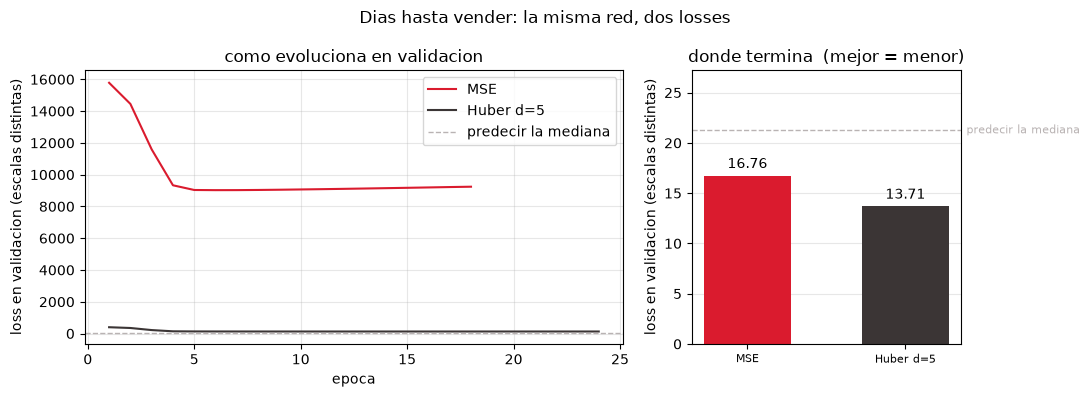

In [6]:
corridas = []
for loss, nombre in [("mse", "MSE"), (keras.losses.Huber(delta=5.0), "Huber d=5")]:
    red, h = entrenar(1, None, loss, y_dias)
    # Se evalua contra los dias REALES, no contra lo cargado.
    pred = red.predict(Xte, verbose=0).ravel()
    mae = float(np.abs(pred - y_limpio[i_te]).mean())
    print(f"{nombre:<12} paro en la epoca {len(h.history['loss']):3}   "
          f"MAE contra los dias reales: {mae:5.2f} dias")
    corridas.append((nombre, h, mae))

base_mae = float(np.abs(y_limpio[i_te] - np.median(y_limpio[i_tr])).mean())
print(f"\nbaseline (predecir siempre la mediana del train): {base_mae:.2f} dias")
comparar("Dias hasta vender: la misma red, dos losses", corridas,
         clave="val_loss", etiqueta_y="loss en validacion (escalas distintas)",
         etiqueta_final="MAE en dias, contra los dias reales", fmt="{:.2f}",
         base=base_mae, nombre_base="predecir la mediana", mejor="menor")

> **Las dos le ganan al baseline, y aun así hay tres días de diferencia entre ellas.** Un error de 1.000 días entra al gradiente **al cuadrado**, así que cada una de las 33 fichas mal cargadas pesa como cientos de fichas normales y tira de la red hacia arriba. Huber las trata como un error más en cuanto se pasan de `delta`, y por eso queda más cerca de la verdad.
>
> Fijate que **el 1,7% de filas sucias se come casi la mitad de lo que la red había ganado sobre el baseline.** No hizo falta que los datos fueran malos: alcanzó con treinta y tres.
>
> Y esto no dice que Huber sea mejor que MSE. Dice que **elegir la loss es afirmar algo sobre los datos.** Si esos 1.000 días fueran reales y no un error de carga, MSE sería lo correcto y Huber estaría ignorando justo los casos que más importan.

## 2 · Un conteo → **1 neurona softplus** · Poisson

Predecir **cuántas visitas** recibe la casa en la primera semana. Es un conteo: entero, nunca negativo, y con una propiedad que MSE no puede representar — **la varianza crece con la media**. Una casa que promedia 1 visita varía poco; una que promedia 20 varía mucho.

Dos cosas fallan si se lo trata como una regresión cualquiera:

- **La salida lineal puede predecir números negativos.** Menos tres visitas no significa nada, y nadie mira las predicciones hasta que alguien las mira.
- **MSE asume varianza constante.** Le pide a la red la misma precisión en las casas de 1 visita que en las de 20, y ese no es el problema.

La salida correcta es **una neurona con `softplus`** — positiva siempre, suave — y la loss es **Poisson**.

In [7]:
y_vis = df.visitas_semana.to_numpy()
print(f"media {y_vis.mean():.2f}   varianza {y_vis.var():.2f}   maximo {y_vis.max():.0f}")
print("en una normal, media y varianza no tienen por que parecerse; en una Poisson\n"
      "son el mismo numero, y por eso la varianza crece con la media.\n")
print(pd.DataFrame({"visitas": list(range(8)) + ["8 o mas"],
                    "casas":   [int((y_vis == v).sum()) for v in range(8)]
                               + [int((y_vis >= 8).sum())]}).to_string(index=False))

media 3.24   varianza 18.96   maximo 54
en una normal, media y varianza no tienen por que parecerse; en una Poisson
son el mismo numero, y por eso la varianza crece con la media.

visitas  casas
      0    463
      1    408
      2    317
      3    212
      4    139
      5    114
      6     81
      7     51
8 o mas    215


lineal + MSE         MAE 1.571   MAE en la cola (>=6 visitas) 3.322   predicciones negativas  5   rango  -0.35 .. 19.10


softplus + Poisson   MAE 1.508   MAE en la cola (>=6 visitas) 3.100   predicciones negativas  0   rango   0.11 .. 13.52

baseline (predecir siempre la media): 2.649   casas con 6 o mas visitas en test: 46


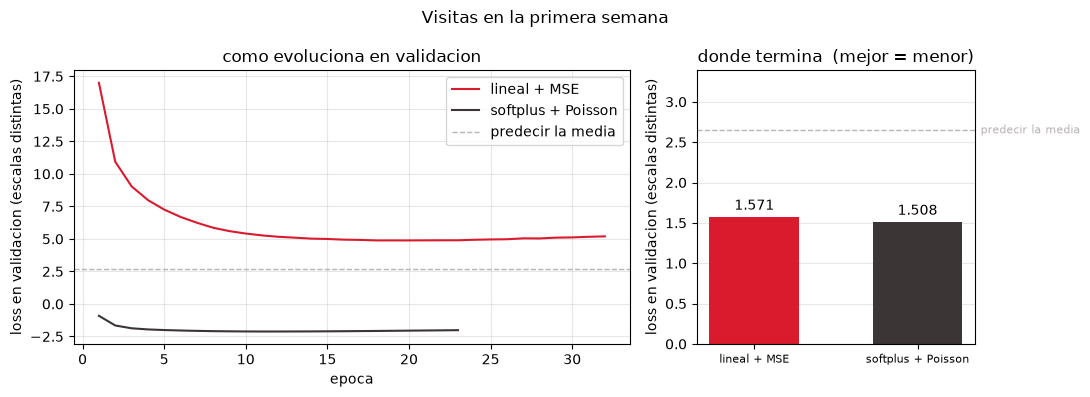

In [8]:
ALTO = 6          # a partir de aca la casa es "muy visitada": son la cola
corridas, detalle = [], []
for act, loss, nombre in [(None, "mse", "lineal + MSE"),
                          ("softplus", keras.losses.Poisson(), "softplus + Poisson")]:
    red, h = entrenar(1, act, loss, y_vis)
    pred = red.predict(Xte, verbose=0).ravel()
    err = np.abs(pred - y_vis[i_te])
    cola = y_vis[i_te] >= ALTO
    mae, mae_cola, neg = float(err.mean()), float(err[cola].mean()), int((pred < 0).sum())
    print(f"{nombre:<20} MAE {mae:5.3f}   MAE en la cola (>={ALTO} visitas) {mae_cola:5.3f}   "
          f"predicciones negativas {neg:2}   rango {pred.min():6.2f} .. {pred.max():5.2f}")
    corridas.append((nombre, h, mae)); detalle.append((mae_cola, neg))

base = float(np.abs(y_vis[i_te] - y_vis[i_tr].mean()).mean())
print(f"\nbaseline (predecir siempre la media): {base:.3f}   "
      f"casas con {ALTO} o mas visitas en test: {int((y_vis[i_te] >= ALTO).sum())}")
comparar("Visitas en la primera semana", corridas, clave="val_loss",
         etiqueta_y="loss en validacion (escalas distintas)",
         etiqueta_final="MAE en visitas", base=base,
         nombre_base="predecir la media", mejor="menor")

> **Dos cosas para leer acá, y la segunda es la que importa.**
>
> La primera: **las curvas de la izquierda no son comparables entre sí**, y quedan en el mismo gráfico a propósito. MSE y Poisson son escalas distintas, así que mirar cuál está más abajo no dice nada. Lo que se compara es el panel de la derecha, que mide las dos en visitas. Es un recordatorio que vale para todo el notebook: **el valor de una loss sirve para ver si esa red mejora, nunca para comparar dos losses entre sí.**
>
> La segunda: la diferencia global en MAE es chica, pero **en la cola es grande, y las predicciones negativas solo las produce MSE.** La ventaja de Poisson no está en el caso promedio — está en que respeta la forma del problema donde el caso promedio no llega.

## 3 · Sí o no → **1 neurona sigmoide** · binary cross-entropy

Predecir **si la casa se vendió**. Una sola neurona con **sigmoide**, que da una probabilidad entre 0 y 1, y **binary cross-entropy** como loss.

La forma incorrecta acá es tratarlo como una regresión: una neurona **sin activación** entrenada con MSE contra un objetivo que vale 0 o 1. Entrena, converge, y hasta acierta parecido. El problema es qué devuelve: **números que no son probabilidades.** Un −0,14 o un 1,20 no se pueden interpretar, no se pueden calibrar y no se pueden umbralizar con sentido.

El par sigmoide + BCE existe justamente para eso: la sigmoide **garantiza** el rango, y BCE es la loss que le corresponde a una probabilidad.

se vendieron 41.0% de las casas (819 de 2000)



lineal + MSE     AUC 0.747   accuracy 0.713   log-loss 0.6887
                 rango de la salida  -0.14 .. 1.07   valores que NO son probabilidades: 17


sigmoide + BCE   AUC 0.773   accuracy 0.720   log-loss 0.5659
                 rango de la salida   0.04 .. 0.92   valores que NO son probabilidades: 0


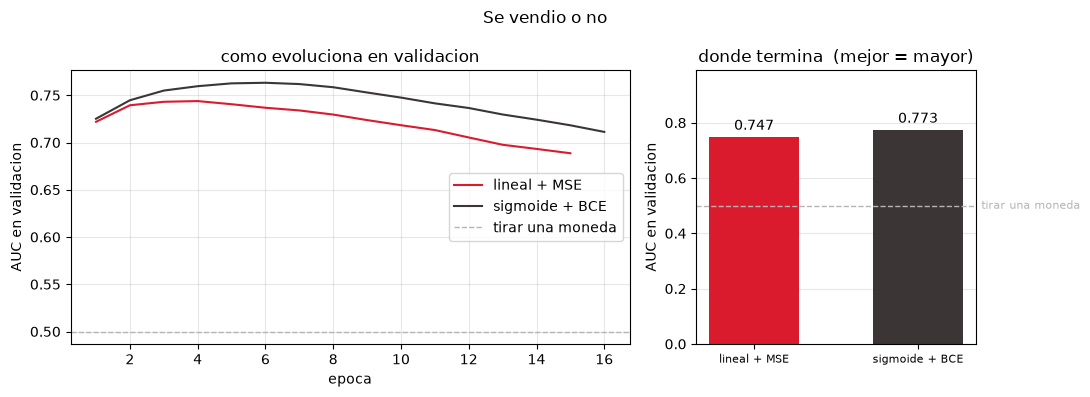

In [9]:
y_vend = df.se_vendio.to_numpy()
print(f"se vendieron {y_vend.mean():.1%} de las casas "
      f"({int(y_vend.sum())} de {len(y_vend)})\n")

def log_loss(y, p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return float(-(y * np.log(p) + (1 - y) * np.log(1 - p)).mean())

corridas = []
for act, loss, nombre in [(None, "mse", "lineal + MSE"),
                          ("sigmoid", "binary_crossentropy", "sigmoide + BCE")]:
    red, h = entrenar(1, act, loss, y_vend, [keras.metrics.AUC(name="auc")])
    p = red.predict(Xte, verbose=0).ravel()
    fuera = int(((p < 0) | (p > 1)).sum())
    auc = float(red.evaluate(Xte, y_vend[i_te], verbose=0)[1])
    print(f"{nombre:<16} AUC {auc:.3f}   accuracy {((p >= .5) == y_vend[i_te]).mean():.3f}   "
          f"log-loss {log_loss(y_vend[i_te], p):.4f}")
    print(f"{'':16} rango de la salida {p.min():6.2f} .. {p.max():.2f}   "
          f"valores que NO son probabilidades: {fuera}")
    corridas.append((nombre, h, auc))

base_auc = 0.5      # tirar una moneda
comparar("Se vendio o no", corridas, clave="val_auc",
         etiqueta_y="AUC en validacion", etiqueta_final="AUC en test",
         base=base_auc, nombre_base="tirar una moneda", mejor="mayor")

> **La diferencia en AUC es real pero modesta, y la estructural no.** La red lineal devuelve valores fuera de \[0, 1\]: no son probabilidades, por más que se parezcan. En cuanto alguien las use para ordenar por riesgo, fijar un umbral de negocio o combinarlas con un costo, ese −0,14 deja de ser una curiosidad.
>
> Es el mismo patrón de la sección anterior: la salida incorrecta **entrena igual**, y el precio se paga en que el número que devuelve no significa lo que uno cree.

## 4 · Una clase entre N → **N neuronas softmax** · cross-entropy

Predecir el **segmento comercial**: económica, media o premium. Las tres son excluyentes — una casa cae en una sola — así que la salida es **tres neuronas con softmax**, que reparten una única unidad de probabilidad, y la loss es **cross-entropy**.

La forma incorrecta es la que más tienta, porque los segmentos *tienen* un orden: numerarlos 0, 1, 2 y predecir ese número con una neurona lineal y MSE. Es el mismo error que en el notebook de la entrada tenía el código postal, pero del lado de la salida: **un segmento no es un número.** Predecir "1,4 de segmento" no responde la pregunta, y la red termina castigada por confundir económica con premium más que por confundirla con media, cuando lo único que interesa es acertar.

In [10]:
seg_i     = df.segmento.cat.codes.to_numpy()             # 0, 1, 2
y_seg_num = seg_i.astype("float32")                      # la forma INCORRECTA
y_seg_1h  = np.eye(3, dtype="float32")[seg_i]            # la forma correcta

print(df.segmento.value_counts().reindex(ORDEN_SEGMENTO).to_string())
print("\nsegmento        ->  numero   ->  one-hot")
for i, s in enumerate(ORDEN_SEGMENTO):
    print(f"  {s:<12}  ->   {float(i):.1f}     ->  {y_seg_1h[seg_i == i][0]}")

segmento
economica    800
media        800
premium      400

segmento        ->  numero   ->  one-hot
  economica     ->   0.0     ->  [1. 0. 0.]
  media         ->   1.0     ->  [0. 1. 0.]
  premium       ->   2.0     ->  [0. 0. 1.]


lineal + MSE, redondeando    accuracy 0.877


softmax + cross-entropy      accuracy 0.923


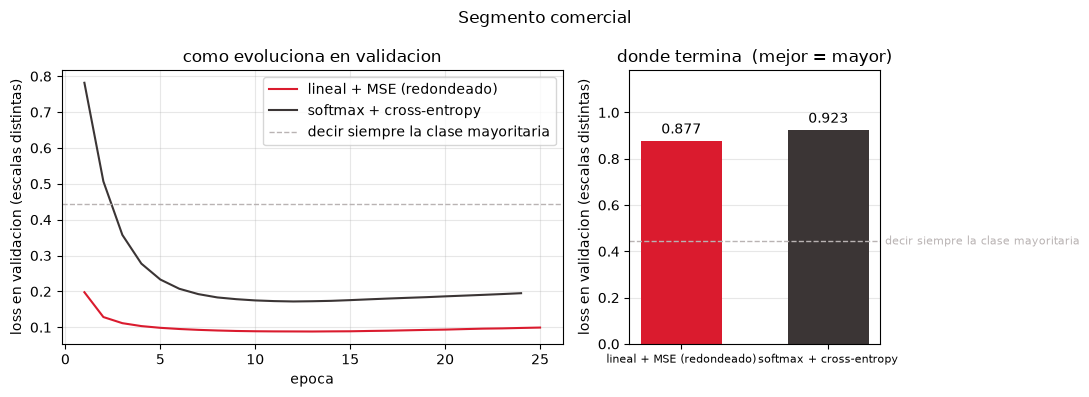

In [11]:
red_num, h_num = entrenar(1, None, "mse", y_seg_num)
# Para poder comparar, el numero continuo se redondea a la clase mas cercana.
pred_num = np.clip(np.round(red_num.predict(Xte, verbose=0).ravel()), 0, 2).astype(int)
acc_num = float((pred_num == seg_i[i_te]).mean())
print(f"lineal + MSE, redondeando    accuracy {acc_num:.3f}")

red_sm, h_sm = entrenar(3, "softmax", "categorical_crossentropy", y_seg_1h,
                        [keras.metrics.CategoricalAccuracy(name="acc")])
acc_sm = float(red_sm.evaluate(Xte, y_seg_1h[i_te], verbose=0)[1])
print(f"softmax + cross-entropy      accuracy {acc_sm:.3f}")

base = float(pd.Series(seg_i[i_te]).value_counts(normalize=True).max())
comparar("Segmento comercial", [("lineal + MSE (redondeado)", h_num, acc_num),
                                ("softmax + cross-entropy", h_sm, acc_sm)],
         clave="val_loss", etiqueta_y="loss en validacion (escalas distintas)",
         etiqueta_final="accuracy en test", base=base,
         nombre_base="decir siempre la clase mayoritaria", mejor="mayor")

## 5 · Varias etiquetas a la vez → **N neuronas sigmoide** · BCE

Predecir tres atributos que **pueden darse juntos**: si tiene pileta, si es apto crédito, si hay que reciclarla. Una casa puede tener las tres, una sola o ninguna.

Acá softmax es un **error de modelado**, no una preferencia. Softmax reparte una única unidad de probabilidad entre las salidas, así que las obliga a competir: subir la probabilidad de "pileta" **baja** la de "apto crédito", cuando en el dato no tienen nada que ver. Es el caso del ticket que es urgente **y** de facturación.

Lo correcto son **N sigmoides independientes**, cada una con su BCE. Cada neurona responde su propia pregunta de sí o no, y no le importa lo que contesten las otras.

In [12]:
Y_lab = df[ETIQUETAS].to_numpy()
n_por_fila = Y_lab.sum(1).astype(int)
print(pd.DataFrame({"etiquetas en la fila": [0, 1, 2, 3],
                    "casas": [int((n_por_fila == k).sum()) for k in range(4)]}
                   ).to_string(index=False))
print(f"\n{(n_por_fila != 1).mean():.1%} de las casas NO tienen exactamente una etiqueta.\n"
      "Para todas esas, softmax no tiene forma de dar una respuesta correcta.")

 etiquetas en la fila  casas
                    0    171
                    1    878
                    2    768
                    3    183

56.1% de las casas NO tienen exactamente una etiqueta.
Para todas esas, softmax no tiene forma de dar una respuesta correcta.


softmax + CE         F1 macro 0.228   suma media de las 3 salidas 1.00
                     por etiqueta: tiene_pileta 0.000   apto_credito 0.449   a_reciclar 0.234


3 sigmoides + BCE    F1 macro 0.623   suma media de las 3 salidas 1.48
                     por etiqueta: tiene_pileta 0.379   apto_credito 0.719   a_reciclar 0.769


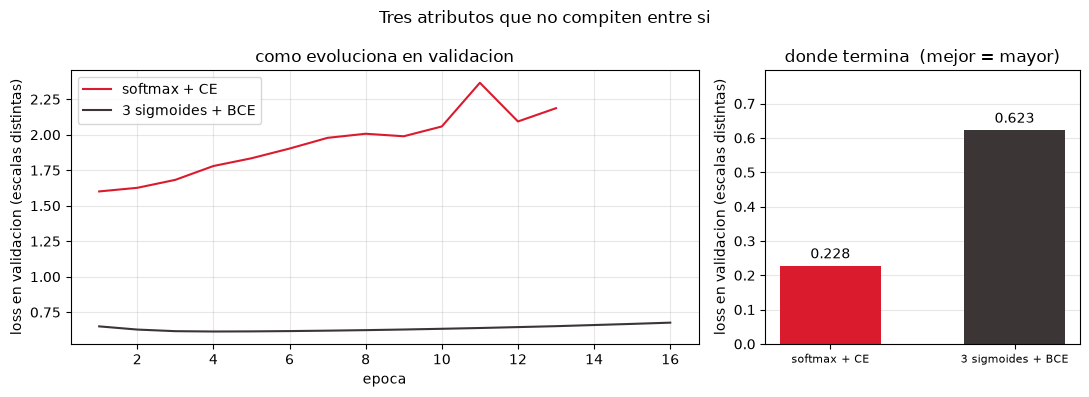

In [13]:
def f1_macro(y_real, prob, umbral=0.5):
    pred, f1s = (prob >= umbral).astype(int), []
    for k in range(y_real.shape[1]):
        tp = int(((pred[:, k] == 1) & (y_real[:, k] == 1)).sum())
        fp = int(((pred[:, k] == 1) & (y_real[:, k] == 0)).sum())
        fn = int(((pred[:, k] == 0) & (y_real[:, k] == 1)).sum())
        f1s.append(0.0 if tp == 0 else 2 * tp / (2 * tp + fp + fn))
    return float(np.mean(f1s)), f1s

corridas = []
for act, loss, nombre in [("softmax", "categorical_crossentropy", "softmax + CE"),
                          ("sigmoid", "binary_crossentropy", "3 sigmoides + BCE")]:
    red, h = entrenar(3, act, loss, Y_lab)
    prob = red.predict(Xte, verbose=0)
    f1, por_etiqueta = f1_macro(Y_lab[i_te], prob)
    print(f"{nombre:<20} F1 macro {f1:.3f}   "
          f"suma media de las 3 salidas {prob.sum(1).mean():.2f}")
    print("                     por etiqueta: " +
          "   ".join(f"{e} {v:.3f}" for e, v in zip(ETIQUETAS, por_etiqueta)))
    corridas.append((nombre, h, f1))

comparar("Tres atributos que no compiten entre si", corridas, clave="val_loss",
         etiqueta_y="loss en validacion (escalas distintas)",
         etiqueta_final="F1 macro en test", mejor="mayor")

> **El número que delata el error es la suma media de las tres neuronas.** Con softmax da exactamente 1,00 **por construcción**: la red *no puede* decir "las tres, con confianza", ni "ninguna". Con sigmoides la suma es libre y refleja cuántas etiquetas tiene realmente la casa.
>
> Mirá el F1 por etiqueta: softmax se queda con una sola y abandona las otras dos, porque es lo único que su forma le permite. **No es que aprenda peor — es que no puede representar la respuesta.**

## 6 · Un rango → **una neurona por percentil** · pinball

La pregunta del negocio no siempre es "¿cuánto tarda?". Muchas veces es **"¿cuánto tardo en el peor caso, para prometerle una fecha al cliente?"**. Eso no lo responde un promedio: lo responde un **percentil**.

La salida es **una neurona lineal por cada percentil que se pida**. Acá pedimos tres — P10, P50, P90 — así que la última capa tiene **3 neuronas**; con P50 y P95 solos serían 2. Ese número lo pone quien modela, a diferencia de las clases o los tags, donde lo pone el problema.

La loss es **pinball**, que castiga asimétrico: para el P90, quedarse corto cuesta nueve veces más que pasarse; para el P10, al revés.

**Cómo se mide.** Un P90 bien calibrado deja **el 90% de los casos reales por debajo**. La métrica es esa cobertura, no el error.

                                   se pidio    se obtuvo
1 neurona + MSE, como si fuera P90    90.0%       47.7%
3 neuronas + pinball, P10            10.0%       15.7%
3 neuronas + pinball, P50            50.0%       48.3%
3 neuronas + pinball, P90            90.0%       81.0%


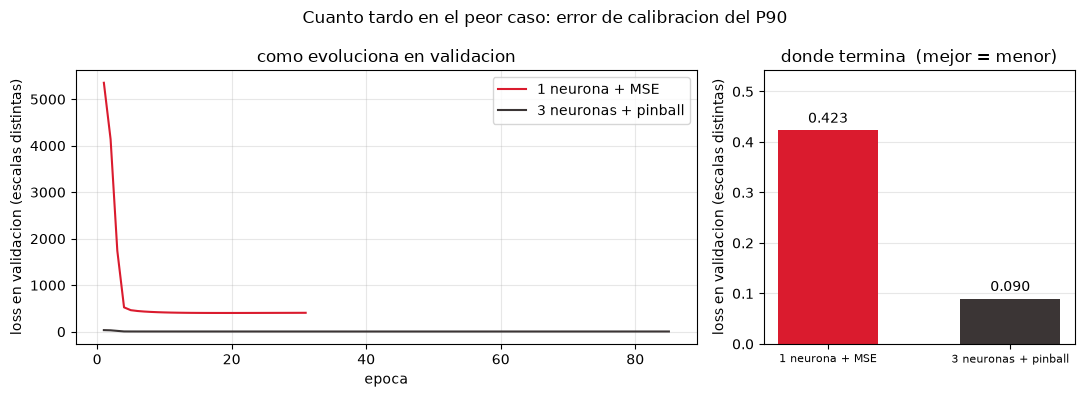

In [14]:
PERCENTILES = [10, 50, 90]        # los que el negocio pide, en porcentaje

def pinball(y_real, y_pred):
    y_real = keras.ops.reshape(y_real, (-1, 1))
    e = y_real - y_pred
    # pinball trabaja con la fraccion, no con el porcentaje
    q = keras.ops.convert_to_tensor(np.array(PERCENTILES, dtype="float32") / 100.0)
    return keras.ops.mean(keras.ops.maximum(q * e, (q - 1.0) * e))

# La forma INCORRECTA: predecir el promedio y usarlo como si respondiera la
# pregunta del peor caso.
red_media, h_media = entrenar(1, None, "mse", y_limpio)
p_media = red_media.predict(Xte, verbose=0).ravel()
cob_media = float((y_limpio[i_te] <= p_media).mean())

red_q, h_q = entrenar(3, None, pinball, y_limpio, paciencia=40, epocas=600)
pred_q = red_q.predict(Xte, verbose=0)
cob_q = [float((y_limpio[i_te] <= pred_q[:, k]).mean()) for k in range(3)]

print("                                   se pidio    se obtuvo")
print(f"1 neurona + MSE, como si fuera P90    90.0%       {cob_media:5.1%}")
for k, pc in enumerate(PERCENTILES):
    print(f"3 neuronas + pinball, P{pc:02}            {pc/100:5.1%}       {cob_q[k]:5.1%}")

comparar("Cuanto tardo en el peor caso: error de calibracion del P90",
         [("1 neurona + MSE", h_media, abs(cob_media - 0.90)),
          ("3 neuronas + pinball", h_q, abs(cob_q[2] - 0.90))],
         clave="val_loss", etiqueta_y="loss en validacion (escalas distintas)",
         etiqueta_final="|cobertura - 0.90|  (0 = perfecto)", mejor="menor")

> **Honestidad sobre estos números:** el P90 entrenado queda alrededor del 82%, no en 90% clavado, y el P10 alrededor del 15%. Con 1400 filas de entrenamiento y una cola tan larga, las puntas son lo más difícil de calibrar y la red se queda corta.
>
> Aun así el contraste es el que importa: el promedio cubre **menos de la mitad** de los casos cuando se lo usa para prometer una fecha. No es que esté "un poco mal calibrado" — es que **no es la respuesta a esa pregunta**, y ninguna cantidad de entrenamiento lo va a convertir en un P90.

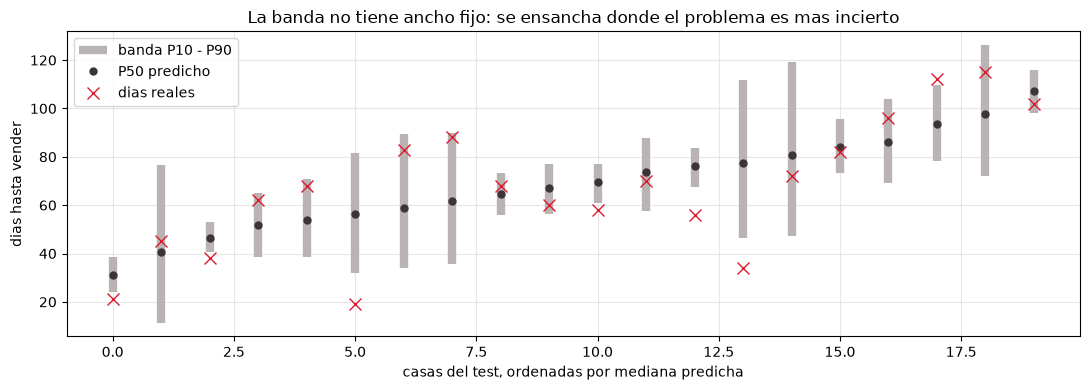

ancho de la banda P10-P90:  minimo 4 dias   medio 35   maximo 82
una regresion comun devuelve un solo numero y no tiene donde poner esa diferencia.


In [15]:
# Los tres percentiles de veinte casas del test, ordenadas por su mediana predicha.
orden = np.argsort(pred_q[:, 1])[::max(1, len(i_te) // 20)][:20]
fig, ax = plt.subplots(figsize=(11, 4))
xs = np.arange(len(orden))
ax.vlines(xs, pred_q[orden, 0], pred_q[orden, 2], color=COLOR_GUIA, lw=6,
          label="banda P10 - P90")
ax.plot(xs, pred_q[orden, 1], "o", color=COLOR_BIEN, ms=5, label="P50 predicho")
ax.plot(xs, y_limpio[i_te][orden], "x", color=COLOR_MAL, ms=8, label="dias reales")
ax.set_xlabel("casas del test, ordenadas por mediana predicha")
ax.set_ylabel("dias hasta vender")
ax.set_title("La banda no tiene ancho fijo: se ensancha donde el problema es mas incierto")
ax.legend(); ax.grid(alpha=.3); fig.tight_layout(); plt.show()

ancho = pred_q[:, 2] - pred_q[:, 0]
print(f"ancho de la banda P10-P90:  minimo {ancho.min():.0f} dias   "
      f"medio {ancho.mean():.0f}   maximo {ancho.max():.0f}")
print("una regresion comun devuelve un solo numero y no tiene donde poner esa diferencia.")

## 7 · Una distribución → **2 neuronas** · NLL gaussiana

El paso final: en vez de un punto o unos percentiles, que la red devuelva **la distribución entera**. Dos neuronas — una para la media `μ`, otra para el desvío `σ` — y la loss es la **log-verosimilitud negativa** de una gaussiana.

`μ` sale lineal, porque puede ser cualquier número. `σ` sale con **softplus**, porque un desvío negativo no existe.

Lo que esto agrega sobre una regresión común es que **`σ` depende de la casa**. En este dataset la incertidumbre la manda el tipo de vivienda: un departamento se vende con una previsibilidad que una casa no tiene. Una regresión con MSE asume un `σ` único para todas, así que le da al departamento el mismo intervalo que a la casa, y ese intervalo miente en los dos.

**Esta sección necesita su propia receta de entrenamiento**, y vale la pena decir por qué: la NLL tiene una forma fácil de hacer trampa, que es **achicar `σ` hasta memorizar los residuos del train**. Sin regularización la red lo hace, y devuelve intervalos ridículamente angostos. Por eso acá van dropout y bastante más paciencia.

In [16]:
def nll_gaussiana(y_real, salida):
    y_real = keras.ops.reshape(y_real, (-1, 1))
    mu = salida[:, 0:1]
    sigma = keras.ops.softplus(salida[:, 1:2]) + 1e-3     # sigma > 0 siempre
    return keras.ops.mean(
        keras.ops.log(sigma) + 0.5 * keras.ops.square((y_real - mu) / sigma))

keras.utils.set_random_seed(42)
red_d = keras.Sequential([
    keras.Input(shape=(X.shape[1],)),
    layers.Dense(64, activation="relu"), layers.Dropout(0.15),
    layers.Dense(32, activation="relu"), layers.Dropout(0.15),
    layers.Dense(2),                      # mu y sigma, sin activacion
])
red_d.compile(optimizer=keras.optimizers.Adam(1e-3), loss=nll_gaussiana)
h_d = red_d.fit(Xtr, y_limpio[i_tr], validation_data=(Xva, y_limpio[i_va]),
                epochs=800, batch_size=LOTE, verbose=0,
                callbacks=[keras.callbacks.EarlyStopping(patience=60,
                                                         restore_best_weights=True)])
salida = red_d.predict(Xte, verbose=0)
mu_d = salida[:, 0]
sigma_d = np.log1p(np.exp(salida[:, 1])) + 1e-3          # el mismo softplus

# La alternativa: MSE, y un sigma unico sacado de los residuos de VALIDACION.
# De train seria mentira: ahi los residuos son chicos porque la red los vio.
res_va = red_media.predict(Xva, verbose=0).ravel() - y_limpio[i_va]
sigma_fijo = float(res_va.std())
print(f"sigma constante (de MSE):   {sigma_fijo:5.1f} dias, el mismo para TODAS las casas")
print(f"sigma aprendido:            de {sigma_d.min():.1f} a {sigma_d.max():.1f} dias, "
      "distinto por casa")

sigma constante (de MSE):    20.0 dias, el mismo para TODAS las casas
sigma aprendido:            de 4.8 a 34.8 dias, distinto por casa


In [17]:
def cobertura(y, mu, sigma, z=1.96):
    return float(((y >= mu - z * sigma) & (y <= mu + z * sigma)).mean())

tipo_te = df.tipo_vivienda.to_numpy()[i_te]
filas = []
for tv in ["departamento", "PH", "duplex", "casa"]:
    m = tipo_te == tv
    filas.append([tv, int(m.sum()), round(float(sigma_d[m].mean()), 1),
                  f"{cobertura(y_limpio[i_te][m], p_media[m], sigma_fijo):.1%}",
                  f"{cobertura(y_limpio[i_te][m], mu_d[m], sigma_d[m]):.1%}"])
filas.append(["TODAS", len(i_te), "-",
              f"{cobertura(y_limpio[i_te], p_media, sigma_fijo):.1%}",
              f"{cobertura(y_limpio[i_te], mu_d, sigma_d):.1%}"])
print(pd.DataFrame(filas, columns=[
    "tipo de vivienda", "casas", "sigma aprendido",
    "cobertura con sigma fijo", "cobertura con sigma aprendido"]).to_string(index=False))
print("\nse pidio un intervalo del 95%: la columna que se acerca mas a 95% en TODAS\n"
      "las filas es la buena, no la que acierta solo en el total.")

tipo de vivienda  casas sigma aprendido cobertura con sigma fijo cobertura con sigma aprendido
    departamento     73            13.8                   100.0%                         98.6%
              PH     82            14.6                   100.0%                         93.9%
          duplex     68            17.2                    94.1%                         94.1%
            casa     77            25.7                    84.4%                         93.5%
           TODAS    300               -                    94.7%                         95.0%

se pidio un intervalo del 95%: la columna que se acerca mas a 95% en TODAS
las filas es la buena, no la que acierta solo en el total.


> **Miralo por fila, no por el total.** Las dos columnas dan alrededor de 95% en el total, y ahí parecen empatadas. La diferencia está adentro: con `σ` constante el intervalo **sobra** en los departamentos y **falta** en las casas — dos errores de signo opuesto que se cancelan al promediar.
>
> Un intervalo que en promedio acierta y en cada caso concreto miente es peor que inútil, porque se lo cree. Eso es exactamente lo que una regresión con MSE no puede evitar: **no tiene dónde poner la información de cuánta incertidumbre hay.**

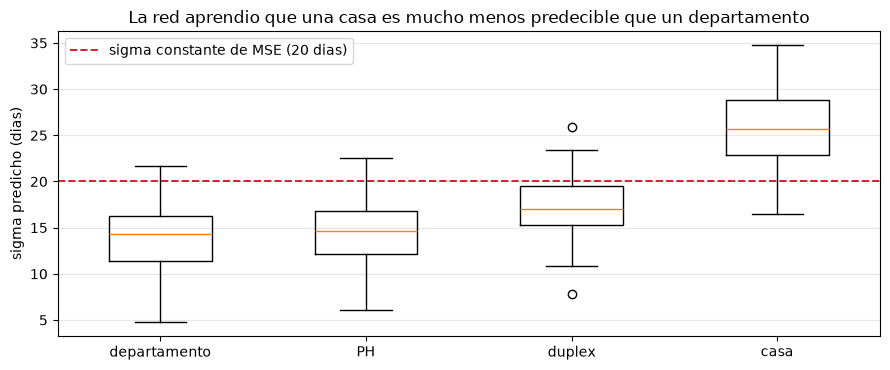

In [18]:
# Donde se ve de una: sigma contra el tipo de vivienda.
fig, ax = plt.subplots(figsize=(9, 3.8))
TIPOS = ["departamento", "PH", "duplex", "casa"]
ax.boxplot([sigma_d[tipo_te == t] for t in TIPOS], tick_labels=TIPOS, widths=.5)
ax.axhline(sigma_fijo, ls="--", lw=1.4, color=COLOR_MAL,
           label=f"sigma constante de MSE ({sigma_fijo:.0f} dias)")
ax.set_ylabel("sigma predicho (dias)")
ax.set_title("La red aprendio que una casa es mucho menos predecible que un departamento")
ax.legend(); ax.grid(alpha=.3, axis="y"); fig.tight_layout(); plt.show()

## La tabla de decisiones, completada

Todo lo de arriba en una fila por tarea. Es la misma tabla de la clase, con el objetivo que le tocó en este notebook.

In [19]:
pd.DataFrame([
    ["Un valor continuo", "1", "ninguna (lineal)",  "MSE / MAE / Huber",    "dias hasta vender"],
    ["Un conteo",         "1", "softplus",          "Poisson",              "visitas en la semana"],
    ["Si o no",           "1", "sigmoide",          "binary cross-entropy", "se vendio"],
    ["Una clase entre N", "N", "softmax",           "cross-entropy",        "segmento comercial"],
    ["Varias etiquetas",  "N", "sigmoide",          "binary cross-entropy", "pileta / credito / reciclar"],
    ["Un rango",          "3", "ninguna (lineal)",  "pinball",              "P10 / P50 / P90 de dias"],
    ["Una distribucion",  "2", "lineal y softplus", "NLL gaussiana",        "mu y sigma de dias"],
], columns=["La tarea", "Neuronas", "Activacion de salida", "Loss", "En este notebook"])

,La tarea,Neuronas,Activacion de salida,Loss,En este notebook
0,Un valor continuo,1,ninguna (lineal),MSE / MAE / Huber,dias hasta vender
1,Un conteo,1,softplus,Poisson,visitas en la semana
2,Si o no,1,sigmoide,binary cross-entropy,se vendio
3,Una clase entre N,N,softmax,cross-entropy,segmento comercial
4,Varias etiquetas,N,sigmoide,binary cross-entropy,pileta / credito / reciclar
5,Un rango,3,ninguna (lineal),pinball,P10 / P50 / P90 de dias
6,Una distribucion,2,lineal y softplus,NLL gaussiana,mu y sigma de dias


> **Sobre la columna "Neuronas":** `1` y `2` son fijos, `N` lo pone el problema — cuántas clases hay, cuántos tags — y el `3` de la fila del rango lo pone **quien modela**: son tantas neuronas como percentiles se pidan. Es la única fila donde el número es una decisión y no un dato.

## Para llevarse

1. **La última capa no se elige: la determina la tarea.** El cuerpo de la red fue **exactamente el mismo** en las siete secciones — `tronco()` no cambió una línea. Lo único que se movió fue cuántas neuronas tiene la salida, con qué activación, y con qué loss se la entrena.
2. **La entrada tampoco cambió.** La misma matriz `X`, los mismos 118 floats, para las siete tareas. Codificar la entrada y modelar la salida son **dos decisiones independientes**: la primera la decide el dato, la segunda la decide la pregunta.
3. **La activación de salida y la loss vienen en par.** Sigmoide con BCE, softmax con cross-entropy, softplus con Poisson. Romper el par no tira un error: da un modelo que anda peor, o que devuelve números que no significan lo que uno cree.
4. **Ninguna de las formas incorrectas falló.** Las siete entrenaron, convergieron y devolvieron un número. Softmax sobre etiquetas no excluyentes es el caso más claro: no es que aprenda mal, es que **no puede representar la respuesta**, y el único síntoma visible es que las tres salidas suman 1,00.
5. **El valor de una loss solo se compara consigo mismo.** MSE contra Poisson, o MSE contra pinball, son escalas distintas: sirven para ver si *esa* red mejora, nunca para decidir cuál de las dos es mejor. Para eso hay que medir las dos con una misma métrica, que es lo que hace el panel derecho de cada comparativa.
6. **Un promedio que acierta en promedio puede mentir en cada caso.** Le pasa al P90 sacado de una media y al intervalo con `σ` constante: el total cierra y cada fila está mal. Percentiles y distribución existen para eso.
7. **Elegir la loss es afirmar algo sobre los datos.** Huber le gana a MSE en los días porque hay fichas mal cargadas. Si esos valores extremos fueran reales, la conclusión se daría vuelta.